# TMR4240 Project – Wind Coefficients

This notebook loads and visualizes the vessel **wind coefficient table**
(`data/wind_coeff.csv`) used by the wind model, and shows how to interpolate it and
turn it into body-frame wind loads.

The table is generated for **R/V Gunnerus** with the empirical method of
**Blendermann (1994)** for the ship type *Research vessel*
(CD_t = 0.85, CD_l = 0.55/0.65 bow/stern, delta = 0.60, kappa = 1.4), using the
windage geometry L_oa = 36.25 m, frontal area A_F = 85 m², lateral area
A_L = 210 m², lateral-area centroid 2.0 m forward of midships (areas are
estimates of the Gunnerus profile). Reference: W. Blendermann, *Parameter
identification of wind loads on ships*, J. Wind Eng. Ind. Aerodyn. 51 (1994);
also Fossen (2021), *Handbook of Marine Craft Hydrodynamics and Motion
Control*, 2nd ed., Sec. 10.1.

The wind loads are computed from the **relative** wind (see `part_1/wind.py`):

$$
\tau_{\text{wind}} = U_{rw}^2 \; C(\alpha_{rw}),
\qquad
C(\alpha) = [C_x,\ C_y,\ C_z,\ C_\phi,\ C_\theta,\ C_\psi]^\top,
$$

where $U_{rw}$ is the relative wind speed and $\alpha_{rw}$ the relative wind angle in the
**body frame**: the direction the relative wind blows *towards*, measured from the bow
axis (tabulated 0°–360°). So $\alpha_{rw} = 0°$ is a **following wind** — blowing from
astern towards the bow — and $\alpha_{rw} = 180°$ is a **head wind** on the bow. Sanity
anchor in the table below: $C_x(0°) = +33.8$ (a following wind pushes forward) and
$C_x(180°) = -28.6$. The coefficients are dimensional — the air density and projected
areas are already absorbed into them ($C_z$ and $C_\theta$ are zero: Blendermann
does not model heave or pitch, and the 3-DOF plant ignores them).

## 1. Load the table

The template provides a loader in `part_1/wind.py`:

In [1]:
import sys
sys.path.insert(0, "..")  # allow running without installing the project package

import numpy as np
import matplotlib.pyplot as plt

from part_1.wind import load_wind_coefficients

alpha_deg, C6 = load_wind_coefficients()

print(f"angle grid : {alpha_deg[0]:.0f} ... {alpha_deg[-1]:.0f} deg, {len(alpha_deg)} points")
print(f"C6 shape   : {C6.shape}   columns = [Cx, Cy, Cz, Cphi, Ctheta, Cpsi]")
print("\nfirst rows:")
print(np.column_stack([alpha_deg, C6])[:4].round(2))

angle grid : 0 ... 360 deg, 37 points
C6 shape   : (37, 6)   columns = [Cx, Cy, Cz, Cphi, Ctheta, Cpsi]

first rows:
[[   0.     33.81   -0.      0.     -0.      0.      0.  ]
 [  10.     34.13   19.44    0.     95.26    0.   -138.24]
 [  20.     34.75   40.86    0.    200.21    0.   -244.01]
 [  30.     34.67   64.67    0.    316.87    0.   -312.54]]


## 2. Plot the coefficients

Same layout as the assignment figure — each coefficient against the relative wind angle:

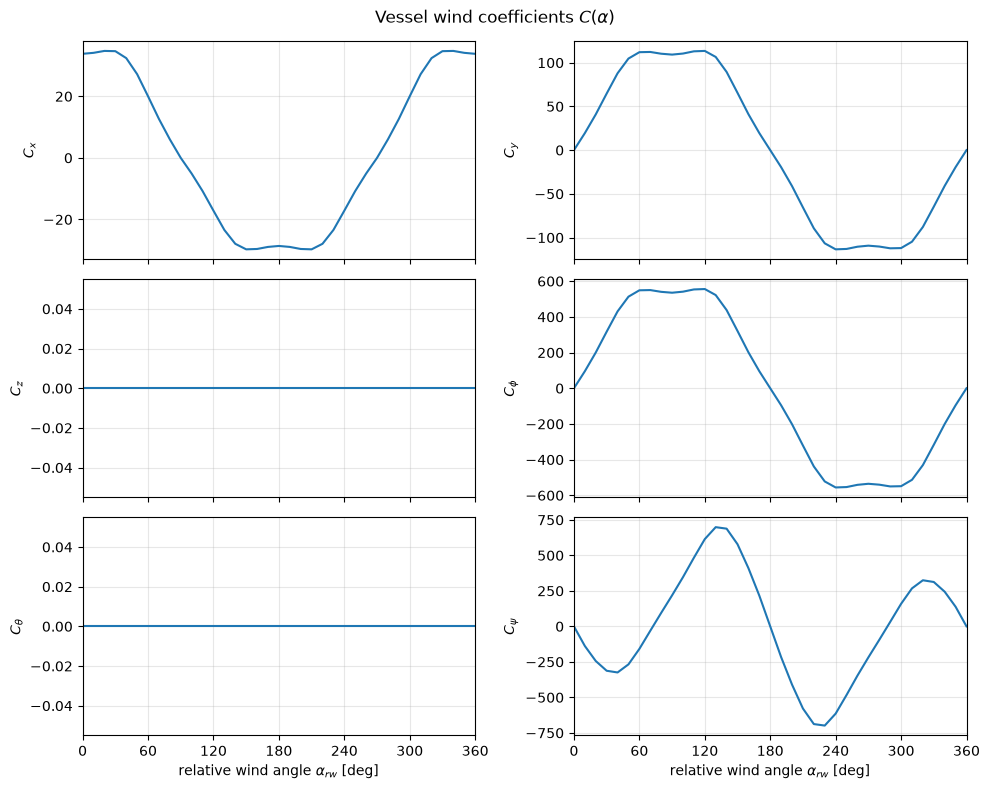

In [2]:
labels = [r"$C_x$", r"$C_y$", r"$C_z$", r"$C_\phi$", r"$C_\theta$", r"$C_\psi$"]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(alpha_deg, C6[:, i])
    ax.set_ylabel(labels[i])
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"relative wind angle $\alpha_{rw}$ [deg]")
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 60))
fig.suptitle("Vessel wind coefficients $C(\\alpha)$")
fig.tight_layout()
plt.show()

Only $C_x$, $C_y$, $C_\psi$ matter for the 3-DOF horizontal-plane model — the surge force,
sway force, and yaw moment. Note the symmetry: $C_x$ is (roughly) even about 180°, while
$C_y$ and $C_\psi$ are odd, as expected for a port/starboard-symmetric vessel.

## 3. Interpolate at an arbitrary angle

The table is periodic in the angle, so interpolate with period 360°:

In [3]:
def wind_coeffs(alpha_rw_deg):
    # interpolate the 6 coefficients at a relative wind angle [deg], periodic in 360
    a = np.mod(alpha_rw_deg, 360.0)
    return np.array([np.interp(a, alpha_deg, C6[:, i], period=360.0) for i in range(6)])

for a in [0, 45, 90, 135, 180]:
    C = wind_coeffs(a)
    print(f"alpha = {a:3d} deg ->  Cx = {C[0]:8.1f}   Cy = {C[1]:8.1f}   Cpsi = {C[5]:9.1f}")

alpha =   0 deg ->  Cx =     33.8   Cy =     -0.0   Cpsi =       0.0
alpha =  45 deg ->  Cx =     29.8   Cy =     96.3   Cpsi =    -296.1
alpha =  90 deg ->  Cx =     -0.0   Cy =    109.2   Cpsi =     218.5
alpha = 135 deg ->  Cx =    -25.7   Cy =     98.0   Cpsi =     693.3
alpha = 180 deg ->  Cx =    -28.6   Cy =      0.0   Cpsi =       0.0


## 4. From coefficients to body-frame loads

Inside your wind model (`Wind.step`), the chain is:

1. Ambient wind in NED: speed $U_w$, direction $\beta_w$ (state your from/towards convention!).
2. **Relative** wind in the body frame: subtract the vessel velocity,
   $\vec V_{rw} = \vec V_{wind} - \vec V_{vessel}$, rotated by $J^\top(\psi)$ — this gives
   $U_{rw}$ and $\alpha_{rw}$.
3. Loads: $\tau_{\text{wind}} = U_{rw}^2\, C(\alpha_{rw})$, of which the simulator uses the
   3-DOF subset $[F_x,\ F_y,\ M_z] = U_{rw}^2\,[C_x,\ C_y,\ C_\psi]$.

Example with a 10 m/s relative wind blowing *towards* the starboard bow
($\alpha_{rw} = 45°$, i.e. coming from the port quarter — it pushes forward and to
starboard):

In [4]:
U_rw = 10.0       # relative wind speed [m/s]
alpha_rw = 45.0   # relative wind angle in body frame [deg]

tau_w6 = U_rw**2 * wind_coeffs(alpha_rw)

print("tau_w6 =", np.round(tau_w6, 1))
print(f"\n3-DOF wind loads:  Fx = {tau_w6[0]:9.1f} N   Fy = {tau_w6[1]:9.1f} N   Mz = {tau_w6[5]:11.1f} Nm")

tau_w6 = [  2980.6   9629.8      0.   47185.8      0.  -29610.6]

3-DOF wind loads:  Fx =    2980.6 N   Fy =    9629.8 N   Mz =    -29610.6 Nm


For Project Part 1 the wind speed has a mean plus a slowly varying component. Any
refinement of the wind field modifies step 1 above — the coefficient lookup (steps 2–3)
stays exactly the same.